In [66]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import random as r 
from mpl_toolkits.mplot3d import Axes3D


In [67]:
def diffkin(par,u):
    th_d=(par[0]/(2*par[1]))*(u[0]-u[1])
    x_d=(par[0]/2)*(u[0]+u[1])*np.cos(par[2])
    y_d=(par[0]/2)*(u[0]+u[1])*np.sin(par[2])
    return [th_d,x_d,y_d]

def rk4(par,xk,uk,dt):
    xk1=(xk.T)[0]
    #print(xk1,xk)
    par1=[par[0],par[1],xk1[0]]
    #print(par1)
    f1=np.array(diffkin(par1,uk))
    f2=np.array(diffkin(par1+f1*dt/2,uk))
    f3=np.array(diffkin(par1+f2*dt/2,uk))
    f4=np.array(diffkin(par1+f3*dt,uk))

    #print(xk1,xk,(dt/6)*(f1+2*f2+2*f3+f4),"===========>",xk1+(dt/6)*(f1+2*f2+2*f3+f4),"][][]")
    return np.array([xk1+(dt/6)*(f1+2*f2+2*f3+f4)]).T


In [68]:
# fig = plt.figure()
# ax=fig.add_subplot()

# d=0.25
# r=0.1
# dt=0.1
# wm=5
# th=0.1

# x=[]
# y=[]
# th=[]
# xk=[1,1,0]
# par=[r,d,th]
# uk=[0.05,0.03]
# pos=[]

# for i in range(1000):
#     xk=rk4(par,xk,uk,dt)
#     pos.append(xk)
#     #print(type(xk))

# for i in range(len(pos)):
#         x.append(pos[i][0]*100)
#         y.append(pos[i][1]*100)
#         th.append(pos[i][2])
# #ax.scatter(x,y)
# ax.plot(x,y)

# ax.set_xlim([-100., 100.])
# ax.set_ylim([-100., 100.])




In [69]:
def rot2(theta):
    return np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

def draw_drive(x,y,theta,d,r,ax):
    rot=rot2(theta)
    #print(rot)

    s1=rot@np.array([[d,r]]).T
    s2=rot@np.array([[d,-r]]).T
    s3=rot@np.array([[-d,-r]]).T
    s4=rot@np.array([[-d,r]]).T
    

    x0=[x+s1[0],x+s2[0],x+s3[0],x+s4[0],x+s1[0]]
    y0=[y+s1[1],y+s2[1],y+s3[1],y+s4[1],y+s1[1]]

    #print(x0,y0)
    ax.plot(x0,y0)



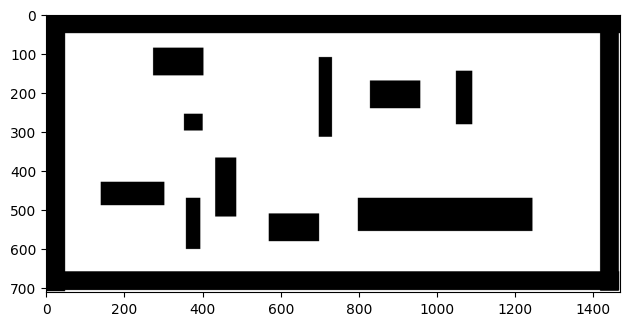

In [70]:
from PIL import Image,ImageOps

img= Image.open("pppp.png")
img= ImageOps.grayscale(img)
np_im=np.array(img)
np_im=~np_im
np_im[np_im>0]=1
plt.set_cmap('binary')
plt.imshow(np_im)

np.save('pppp.npy',np_im)

grid=np.load("pppp.npy")

plt.imshow(grid)
plt.tight_layout()
plt.show()



In [71]:
# fig = plt.figure()
# ax=fig.add_subplot()

# ax.plot(x,y)
# print(x[-1],y[-1])
# draw_drive(x[-1],y[-1],0.2,d*100,r*100,ax)



# ax.imshow(grid)

Since we have made a basic workspace for our differencial drive we recognise the landmark to create the first implemantation of the particle filter

In [72]:

pos=(500,500)
print(grid[pos])
if(grid[pos]==1):
    print(pos)

0


In [73]:
def find_rectangle_obstacles(grid):
    
    working_grid = grid.copy()
    rectangles = []
    height, width = grid.shape
    
    for y in range(height):
        for x in range(width):
            if working_grid[y, x] == 1:  
                
                rect_width = 1
                while x + rect_width < width and working_grid[y, x + rect_width] == 1:
                    rect_width += 1
                
                
                rect_height = 1
                valid_height = True
                while valid_height and y + rect_height < height:
                    
                    for dx in range(rect_width):
                        if working_grid[y + rect_height, x + dx] != 1:
                            valid_height = False
                            break
                    if valid_height:
                        rect_height += 1
                
                
                rectangles.append([x, y, rect_width, rect_height])
                
                
                working_grid[y:y+rect_height, x:x+rect_width] = 0
                
    return rectangles

In [74]:
obstacles=find_rectangle_obstacles(grid)
print(obstacles[0])
print(obstacles[0][0],obstacles[0][1])

fig = plt.figure()
ax=fig.add_subplot()

#draw_drive(obstacles[0][0],obstacles[0][1],0,d*100,r*100,ax)

ax.imshow(grid)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\vagge\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\vagge\AppData\Local\Temp\ipykernel_31396\1097724181.py", line 1, in <module>
    obstacles=find_rectangle_obstacles(grid)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vagge\AppData\Local\Temp\ipykernel_31396\786966689.py", line -1, in find_rectangle_obstacles
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\vagge\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vagge\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\ultratb.py", li

Μοντελοποιουμε το Lidar

In [ ]:
def colliding(x,y,grid):
    try:
        if (grid[int(y)][int(x)])==1:
            return True
    except:
        return False
    return False
def collision_check(x,y,d,r,grid):
    r_c=np.sqrt(d**2+r**2)*1.02 #σαν ελαχιστη ακτινα περνουμε λιγο περισσοτερο απο την μεγαλυτερη ακρη του ρομποτ
    st_th=np.pi/18 #βαζουμε ενα sample rate ~ ανα 10 μοιρες (μπορει να γινει παραπανω)
   
    
    for i in range(37):
        #print(i,grid[int(y+r_c*np.sin(st_th*i))][int(x+r_c*np.cos(st_th*i))])
        try:
            if (grid[int(y+r_c*np.sin(st_th*i))][int(x+r_c*np.cos(st_th*i))])==1:
                return False
        except:
            return False
    return True

#οπτικοποιουμε τις ακτινες του lidar
def collision_check_show(x,y,d,r,ax):
    
    r_c=np.sqrt(d**2+r**2)*1.02 
    st_th=np.pi/18

    xs=[]
    ys=[]

    for i in range(37):
        ch_pos=[x+r_c*np.cos(st_th*i),y+r_c*np.sin(st_th*i)]

        #print(grid[int(ch_pos[1])][int(ch_pos[0])])
        xs.append(ch_pos[0])
        ys.append(ch_pos[1])
    
    ax.plot(xs,ys)

In [ ]:
def closest_corner(robot_state, landmark_state):
    
    closest_x = np.clip(robot_state[0], 
                        landmark_state[0] , 
                        landmark_state[0] + landmark_state[2])
    
    closest_y = np.clip(robot_state[1], 
                        landmark_state[1] , 
                        landmark_state[1] + landmark_state[3])
    #print(np.array([robot_state[1],robot_state[2]]))
    fff=np.array([robot_state[1],robot_state[2]]) - np.array([closest_x, closest_y])
    #print(fff)
    return fff

def robot_landmark_2d_measurement(robot_state, landmark_state):
    #print(robot_state,landmark_state)
    cl=closest_corner(robot_state, landmark_state)
    
    dx1=cl[0][0]
    dy1=cl[1][0]
    #print("{}{}{}{}{}{}{}{}{}{}{}{}",np.arctan2(dy1,dx1)-robot_state[0,0],dy1,dx1)
    
    dtheta=np.arctan2(dy1,dx1)-robot_state[0,0] 
    if (dtheta>np.pi):
        dtheta=dtheta-2*np.pi
    elif(dtheta<-np.pi):
        dtheta=dtheta+2*np.pi

    dis=(np.sqrt(np.square(dx1)+np.square(dy1)),dtheta)
    
    return dis
    

def lidar(x, landmarks, max_dis, width = 2. * np.pi, noise = (1e-3,1e-3)):
    detects = []
    for k in range(len(landmarks)):
        #print(x)
        #print(landmarks[k][:2])
        it=robot_landmark_2d_measurement(x, landmarks[k])
        #print(it)
        n1=1+np.random.normal(0,noise[0])
        n2=1+np.random.normal(0,noise[1])
        #print("+++>",it[0])
        if((abs(it[1])<(width/2))&(it[0]<max_dis)):
            it=(it[0]*n1,it[1]*n2,k+1)
            detects.append(it)
        else:
            detects.append("none")
    return detects

def lidar2(x, landmarks, max_dis, width = 2. * np.pi, noise = (1e-3,1e-3)):
    detects = []
    for k in range(36):
        theta=k*width/36
        for j in range(10):
            dis=j*max_dis/10
            pos=(dis*np.cos(theta),dis*np.sin(theta))
            if(grid[pos]==1):
                detects.append(pos)
                break
    return detects

def lidar_show(x, r_c, ax, width = 2. * np.pi):
    x_c=x[1]
    y_c=x[2]

    st_th=width/36

    xs=[]
    ys=[]

    for i in range(37):
        ch_pos=[x_c+r_c*np.cos(st_th*i),y_c+r_c*np.sin(st_th*i)]

        #print(grid[int(ch_pos[1])][int(ch_pos[0])])
        xs.append(ch_pos[0])
        ys.append(ch_pos[1])
    
    for i in range(37):
        ch_pos=[x_c+r_c*np.cos(st_th*i),y_c+r_c*np.sin(st_th*i)]

        #print(grid[int(ch_pos[1])][int(ch_pos[0])])
        xs.append(ch_pos[0])
        ys.append(ch_pos[1])
        xs.append(x_c)
        ys.append(y_c)

    ax.plot(xs,ys)

def lidar_show_col(x, r_c, ax, width = 2. * np.pi):
    x_c=x[1]
    y_c=x[2]

    st_th=width/36

    xs=[]
    ys=[]

    for i in range(37):
        ch_pos=[x_c+r_c*np.cos(st_th*i),y_c+r_c*np.sin(st_th*i)]

        #print(grid[int(ch_pos[1])][int(ch_pos[0])])
        xs.append(ch_pos[0])
        ys.append(ch_pos[1])
    
    for i in range(37):
        ch_pos=[x_c+r_c*np.cos(st_th*i),y_c+r_c*np.sin(st_th*i)]

        #print(grid[int(ch_pos[1])][int(ch_pos[0])])
        xs.append(ch_pos[0])
        ys.append(ch_pos[1])
        xs.append(x_c)
        ys.append(y_c)

    ax.plot(xs,ys)

In [ ]:
print(grid[(250,300)])

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()

width=2*np.pi
max_dis=150
x = np.array([[0., 400, 200]]).T

detects = []
xs=[]
ys=[]
x_c=x[1,0]
y_c=x[2,0]

for k in range(36):
    theta=k*width/36
    
    for j in range(15):
        dis=j*max_dis/15
        pos=(int(y_c+dis*np.cos(theta)),int(x_c+dis*np.sin(theta)))
        try:
            if(grid[pos]==1):
                #print(dis,theta)
                detects.append(pos)
                #print(pos[0])
                #print(grid[pos])
                xs.append(pos[1])
                ys.append(pos[0])
                xs.append(x_c)
                ys.append(y_c)
                break
        except:
            continue
        #print(pos,dis,theta*180/(np.pi))

print(xs,ys)
ax.plot(xs,ys)

ax.imshow(grid)

In [ ]:
def Lidar3(x,accuracy, max_dis, width = 2. * np.pi, noise = (1e-3,1e-3),grid=grid):
    x_c=x[1,0]
    y_c=x[2,0]
    detects = np.empty((0, 2))
    #print(x)
    inst_theta=accuracy[0]
    inst_length=accuracy[1]
    for k in range(inst_theta):
        theta=(k*width/inst_theta+x[0,0])*(1+np.random.normal(0,noise[0]))
    
        for j in range(inst_length):
            dis=(j*max_dis/inst_length)*(1+np.random.normal(0,noise[1]))
            
            pos=(int(y_c+dis*np.cos(theta)),int(x_c+dis*np.sin(theta)))
            try:
                if(grid[pos]==1):
                    #print(dis,theta)
                    #print(detects, [dis,theta])
                    detects=np.vstack((detects, [theta,dis]))
                    
                    break
            except:
                continue
    return detects    

def Lidar3_show(x,accuracy,ax, max_dis=150, width = 2. * np.pi, noise = (1e-3,1e-3)):
    x_c=x[1,0]
    y_c=x[2,0]
    detects = []
    xs=[]
    ys=[]
    inst_theta=accuracy[0]
    inst_length=accuracy[1]
    print(inst_length)
    #print(inst_length,inst_theta)
    for k in range(1,inst_theta):
        theta=(k*width/inst_theta+x[0,0])*(1+np.random.normal(0,noise[0]))
        #print(inst_theta)
        for j in range(1,inst_length):
            #print(inst_length)
            dis=(j*max_dis/inst_length)*(1+np.random.normal(0,noise[1]))
            pos=(int(y_c+dis*np.cos(theta)),int(x_c+dis*np.sin(theta)))
            #print((j*max_dis/inst_length)*(1+np.random.normal(0,noise[1])))
            try:
                if(grid[pos]==1):
                    print(dis,theta)
                    detects.append(pos)
                    xs.append(pos[1])
                    ys.append(pos[0])
                    xs.append(x_c)
                    ys.append(y_c)                    
                    break
            except:
                continue
    ax.plot(xs,ys)
    return detects  

In [ ]:
x = np.array([[0., 300, 300]]).T
print(Lidar3(x,(36,10),150))

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()
x = np.array([[0., 300, 300]]).T

#draw_drive(x[1],x[2],0,d*100,r*100,ax)
det=Lidar3_show(x,(36,10),ax)


ax.imshow(grid)

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()
x = np.array([[0., 200, 300]]).T

detects = lidar(x, obstacles, 200.)

#draw_drive(x[1],x[2],0,d*100,r*100,ax)
print(detects)
#collision_check_show(x[1],x[2],d*100,r*100,ax)
lidar_show(x, 150, ax, width = 2. *np.pi)

ax.imshow(grid)

In [ ]:
def likelihood(x, y, sigma=1.0):
    # Gaussian likelihood: P(x | y) = N(x; y, sigma²)
    exponent = -0.5 * ((x - y) / sigma) ** 2
    normalization = 1.0 / (sigma * np.sqrt(2 * np.pi))
    return normalization * np.exp(exponent)

def log_likelihood(x, y, sigma=1.0):
    return -0.5 * ((x - y) / sigma) ** 2 - np.log(sigma * np.sqrt(2 * np.pi))

In [ ]:
def canonicalize_angle(angle):
    # Normalize the angle to be within [-pi, pi]
    return np.arctan2(np.sin(angle), np.cos(angle))

def compute_particle_weight2_inst(real_meas, pred_meas, sigma_r, sigma_theta):
    
    # Calculate the difference in angle and distance
    delta_angle = canonicalize_angle(real_meas[0] - pred_meas[0])
    delta_distance = real_meas[1] - pred_meas[1]
    
    # Normalize the angle difference to be within [-pi, pi]
    delta_angle = np.arctan2(np.sin(delta_angle), np.cos(delta_angle))
    
    # Calculate the weight using Gaussian distribution
    weight = (1/(2*np.pi*sigma_r*sigma_theta)) * np.exp(-0.5 * ((delta_distance/sigma_r)**2 + (delta_angle/sigma_theta)**2))
    
    return weight

def detertmine_closest_particle(real_meas, pred_meas):
    min=np.inf
    min_index=-1
    #print("real meas is ",real_meas)
    #print("pred meas is ",pred_meas)    
    for meas in range(len(real_meas)):
        dr=real_meas[meas][1]-pred_meas[1]
        dtheta=real_meas[meas][0]-pred_meas[0]
        if abs(dr)<min:
            min=abs(dr)
            min_index=meas
    #print("closest particle index is ",min_index)
    #print("closest particle distance is ",min)
    #print("closest particle angle is ",dtheta)
    return min_index


#detertmine_closest_particle(np.array([0.5, 1.0]), np.array([[0.1, 0.9], [0.4, 1.2], [0.6, 1.5]]))  
        
def determine_weight_inst(real_meas,pred_meas,thres_r,thres_theta, sigma_r, sigma_theta):
    #print("real meas is ",real_meas)
    #print("pred meas is ",pred_meas)
    dr=real_meas[1]-pred_meas[1]
    dtheta=real_meas[0]-pred_meas[0]
    
    if abs(dr)>thres_r or abs(dtheta)>thres_theta:
        return 0.0
    else:
        return compute_particle_weight2_inst(real_meas, pred_meas, sigma_r, sigma_theta)
    
print(determine_weight_inst(np.array([0.5, 1.0]), np.array([0.4, 1.0]), 0.5, 0.5, 0.15, 1.5))

def probabill(real_meas,pred_meas,thres_r,thres_theta, sigma_r, sigma_theta):
    weights=[]
    for meas in range(len(pred_meas)):
        pick=detertmine_closest_particle(real_meas, pred_meas[meas])
        weights.append(determine_weight_inst(real_meas[pick], pred_meas[meas], thres_r, thres_theta, sigma_r, sigma_theta))
        #print("weight of particle ",meas," is ",weights)
    return weights

#bil=probabill(np.array([0.5, 1.0]), np.array([[0.4, 1.0], [0.6, 1.2], [0.8, 1.5]]), 0.5, 0.5, 0.15, 1.5)

def normalize_weights(weights):
    total_weight = np.sum(weights)
    if total_weight == 0:
        return weights
    return weights / total_weight

def systematic_resample(weights):
    N = len(weights)
    # Generate a single random offset
    u = (np.random.random() + np.arange(N)) / N
    #print("u is ",u)
    # Compute cumulative weights
    cum_weights = np.cumsum(weights)
    cum_weights /= cum_weights[-1]  # Normalize
    #print("cumulative weights are ",cum_weights)
    # Resampled indices
    indices = np.zeros(N, dtype=int)
    i = 0
    for j in range(N):
        while u[j] > cum_weights[i]:
            i += 1
        indices[j] = i
    
    return indices

def predict_instance(particle,par, u, dt):
    #print("particle is ",particle)
    rk4_par = rk4(par, particle, u, dt)  
    #print("predicted particle is ",rk4_par)
    return rk4_par

In [ ]:
pp=systematic_resample(np.array([0.1, 0.2, 0.3, 0.4, 0.5]))

print("resampled particles are ",pp)

In [ ]:
def line_similarity_weight(line1, line2, angle_weight=0.3, length_weight=0.2):
    # Extract points
    p1_start = np.array([line1[0], line1[1]])
    p1_end = np.array([line1[2], line1[3]])
    p2_start = np.array([line2[0], line2[1]])
    p2_end = np.array([line2[2], line2[3]])
    
    # --- 1. Endpoint distances (normalized by line length) ---
    start_dist = np.linalg.norm(p1_start - p2_start)
    end_dist = np.linalg.norm(p1_end - p2_end)
    avg_length = (np.linalg.norm(p1_end - p1_start) + np.linalg.norm(p2_end - p2_start)) / 2
    endpoint_sim = 1.0 - (start_dist + end_dist) / (2 * avg_length + 1e-6)  # Add epsilon to avoid division by zero
    
    # --- 2. Angle similarity (cosine similarity) ---
    vec1 = p1_end - p1_start
    vec2 = p2_end - p2_start
    cos_sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-6)
    angle_sim = (cos_sim + 1) / 2  # Convert from [-1, 1] to [0, 1]
    
    # --- 3. Length similarity (optional) ---
    len1 = np.linalg.norm(vec1)
    len2 = np.linalg.norm(vec2)
    length_sim = 1.0 - np.abs(len1 - len2) / (max(len1, len2) + 1e-6)
    
    # --- Combine weights ---
    weight = (
        (1.0 - angle_weight - length_weight) * endpoint_sim 
        + angle_weight * angle_sim 
        + length_weight * length_sim
    )
    
    return np.clip(weight, 0.0, 1.0)

def distance_weight(line1, line2):
        try:
            x1_1, y1_1, x2_1, y2_1 = line1
            x1_2, y1_2, x2_2, y2_2 = line2
        except ValueError:
            #print("!!!!!!!!!!!", line1, line2)
            return 0.0
        # Calculate line centers
        center1 = ((x1_1 + x2_1) / 2, (y1_1 + y2_1) / 2)
        center2 = ((x1_2 + x2_2) / 2, (y1_2 + y2_2) / 2)
        
        # Distance between centers
        center_dist = np.sqrt((center1[0] - center2[0])**2 + (center1[1] - center2[1])**2)
        
        # Minimum distance between endpoints
        distances = [
            np.sqrt((x1_1 - x1_2)**2 + (y1_1 - y1_2)**2),  # start to start
            np.sqrt((x1_1 - x2_2)**2 + (y1_1 - y2_2)**2),  # start to end
            np.sqrt((x2_1 - x1_2)**2 + (y2_1 - y1_2)**2),  # end to start
            np.sqrt((x2_1 - x2_2)**2 + (y2_1 - y2_2)**2)   # end to end
        ]
        min_endpoint_dist = min(distances)
        
        # Combine distances (inverse relationship - closer = higher weight)
        avg_dist = (center_dist + min_endpoint_dist) / 2
        return 1 / (1 + avg_dist) if avg_dist > 0 else 1.0

def find_most_similar_line(target_line, candidate_lines):
    max_weight = -1
    best_line = None
    
    for candidate in candidate_lines:
        weight = distance_weight(np.concatenate(target_line), np.concatenate(candidate))
        if weight > max_weight:
            max_weight = weight
            best_line = candidate
    
    return best_line, max_weight

def merge_lines(line1, line2):
    (x1, y1), (x2, y2) = line1
    (x3, y3), (x4, y4) = line2

    # Check if the lines are collinear (lie on the same infinite line)
    def are_collinear():
        # Cross-product to check collinearity
        cross1 = (x2 - x1) * (y3 - y1) - (y2 - y1) * (x3 - x1)
        cross2 = (x2 - x1) * (y4 - y1) - (y2 - y1) * (x4 - x1)
        return cross1 == 0 and cross2 == 0

    if not are_collinear():
        return (line1, line2)  # Lines are not collinear, no overlap

    # Project points onto parametric form (t) to check overlap
    def project(point):
        # If line is vertical, use y-coordinate; else, use x-coordinate
        if x1 == x2:
            return point[1]  # Vertical line → project onto y-axis
        else:
            return point[0]  # Non-vertical → project onto x-axis

    # Get min and max projections for each line
    t1_min, t1_max = sorted([project(line1[0]), project(line1[1])])
    t2_min, t2_max = sorted([project(line2[0]), project(line2[1])])

    # Check if projections overlap
    if t1_max < t2_min or t2_max < t1_min:
        return (line1, line2)  # No overlap

    # Merge the lines by taking the extreme points
    all_points = [line1[0], line1[1], line2[0], line2[1]]
    if x1 == x2:  # Vertical line → sort by y-coordinate
        merged = (min(all_points, key=lambda p: p[1]), max(all_points, key=lambda p: p[1]))
    else:  # Non-vertical → sort by x-coordinate
        merged = (min(all_points, key=lambda p: p[0]), max(all_points, key=lambda p: p[0]))

    return merged
   
def merge_of_lines(set1, set2):
    """
    Merges overlapping lines between two sets of line segments.
    
    Args:
        set1: List of lines in the form [[x1, y1], [x2, y2]]
        set2: List of lines in the same format
        
    Returns:
        A new set of lines where overlapping lines from set1 and set2 are merged.
    """
    merged = []
    used_lines = set()  # Track indices of lines that have been merged
    
    for i, line1 in enumerate(set1):
        if i in used_lines:
            continue  # Skip if already merged
        
        for j, line2 in enumerate(set2):
            if j in used_lines:
                continue  # Skip if already merged
            
            result = merge_lines(line1, line2)
            
            # If lines were merged, replace line1 and mark line2 as used
            if isinstance(result, list) and len(result) == 2:
                line1 = result  # Update line1 to the merged version
                used_lines.add(j)  # Mark line2 as merged
        
        merged.append(line1)  # Add the (possibly merged) line1
    
    # Add remaining lines from set2 that weren't merged
    for j, line2 in enumerate(set2):
        if j not in used_lines:
            merged.append(line2)
    
    return merged

def create_line_boxes(lines, box_width, image_size=(100, 100), img=None):
    #print(lines)
    if img is None:
        img = np.zeros(image_size, dtype=np.uint8)
    
    h, w = image_size
    box_radius = max(1, box_width // 2)
    
    # Create coordinate grids
    y_grid, x_grid = np.indices((h, w))
    
    for (x1, y1), (x2, y2) in lines:
        # Vector calculations for line properties
        dx = x2 - x1
        dy = y2 - y1
        line_length_sq = dx*dx + dy*dy
        
        # Handle zero-length lines (points)
        if line_length_sq == 0:
            # Create a box around the single point
            x_min = max(0, int(x1 - box_radius))
            x_max = min(w, int(x1 + box_radius + 1))
            y_min = max(0, int(y1 - box_radius))
            y_max = min(h, int(y1 + box_radius + 1))
            img[y_min:y_max, x_min:x_max] = 1
            continue
        
        # Calculate projection of all points onto the line segment
        t = np.clip(((x_grid - x1) * dx + (y_grid - y1) * dy) / line_length_sq, 0, 1)
        proj_x = x1 + t * dx
        proj_y = y1 + t * dy
        
        # Calculate distance from all points to the line segment
        dist_sq = (x_grid - proj_x)**2 + (y_grid - proj_y)**2
        
        # Create mask for points within box_width of the line
        mask = dist_sq <= box_radius**2
        
        # Update image with this line's box
        img = np.logical_or(img, mask)
    
    return img.astype(np.uint8)

def to_cart_inst(part,meas):
    return np.array([meas[0]+part[0],part[1]+meas[1]*np.sin(meas[0]),part[2]+meas[1]*np.cos(meas[0])]).T

def to_cart_all(part,meas):
    out=np.zeros((len(meas),3))
    for i in range(len(meas)):
        out[i]=to_cart_inst(part,meas[i])
    return out

def get_segment_boundaries(coords, threshold):
    if len(coords) == 1:
        return [(coords[0].tolist(), coords[0].tolist())]
    
    xy_coords = coords[:, 1:3]  # Take columns 1 and 2 (x and y)
    
    diffs = np.diff(xy_coords, axis=0)
    distances = np.sqrt(np.sum(diffs**2, axis=1))
    
    split_indices = np.where(distances > threshold)[0] + 1
    
    all_indices = np.concatenate(([0], split_indices, [len(coords)]))
    
    segments = []
    for i in range(len(all_indices)-1):
        start_idx = all_indices[i]
        end_idx = all_indices[i+1] - 1
        try:
            segments.append((coords[start_idx].tolist(), coords[end_idx].tolist()))
        except IndexError:
            return []
    lines=[]
    for segment in segments:
        lines.append((segment[0][1:], segment[1][1:]))  # Exclude the first element (angle)
    return lines

 

def divide_into_lines_1(points, distance_threshold, angle_threshold_deg):
    # Convert input to numpy array if it isn't already
    points = np.asarray(points)
    
    # Handle empty/small cases
    if len(points) < 2:
        return [points.copy()] if len(points) > 0 else []
    
    lines = [[points[0]]]  # Start first line with first point
    angle_threshold = np.radians(angle_threshold_deg)
    
    for i in range(1, len(points)):
        current_point = points[i]
        current_line = lines[-1]
        last_point = current_line[-1]
        
        # Calculate distance to last point
        distance = np.linalg.norm(current_point - last_point)
        
        # Check distance threshold
        if distance > distance_threshold:
            lines.append([current_point])
            continue
        
        # Only check angle if we have at least 2 points in current line
        if len(current_line) >= 2:
            prev_point = current_line[-2]
            
            # Vector from previous to last point
            vec1 = last_point - prev_point
            # Vector from last to current point
            vec2 = current_point - last_point
            
            # Normalize vectors
            norm1 = np.linalg.norm(vec1)
            norm2 = np.linalg.norm(vec2)
            
            if norm1 > 1e-6 and norm2 > 1e-6:  # Avoid division by zero
                # Calculate angle between vectors
                cos_angle = np.dot(vec1, vec2) / (norm1 * norm2)
                cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Ensure valid range
                angle = np.arccos(cos_angle)
                
                # Check angle threshold
                if angle > angle_threshold:
                    lines.append([current_point])
                    continue
        
        # If passed both checks, add to current line
        current_line.append(current_point)
    
    # Simplify to first and last points only
    simplified_lines = []
    for line in lines:
        if len(line) == 1:
            simplified_lines.append(([line[0]]))
        else:
            simplified_lines.append(([line[0], line[-1]]))
    
    return simplified_lines

In [ ]:
class Line():
    def __init__(self, start, end,measurement_noise_std=0.05):
        self.start = np.array(start)
        self.end = np.array(end)
        self.covariance = np.eye(4)*measurement_noise_std**2
    def __str__(self):
        return f"Line(start={self.start}, end={self.end}, covariance={self.covariance})"
    def ekf_update_line(self, measurement,measurement_noise_std=0.1):

        R = np.eye(4)*(1*measurement_noise_std)
        z= np.array(measurement)
        mu_old=np.concatenate([self.start,self.end])
        #print(mu_old)
        Gn = np.eye(4)

        innovation = np.concatenate([z[0] - self.start, z[1] - self.end])
        #print("Innovation:", innovation)
        Qn= Gn @ self.covariance @ Gn.T + R
        K = self.covariance @ Gn.T @ np.linalg.inv(Qn)
        mu_2 = mu_old + K @ innovation
        S_new= (np.eye(4) - K @ Gn) @ self.covariance
        
        self.start = mu_2[:2]
        self.end = mu_2[2:]
        
        
        self.covariance = S_new
        

In [ ]:
class Map():
    def __init__(self,grid=None):
        if grid is None:
            grid = np.zeros((700, 1400), dtype=int)
            np.save("belief.npy", grid)
        self.grid=grid
        self.noise=(1e-3,1e-3)
        self.lines=[]
        self.part=[]
        self.ess_lst=[]
        self.num_part=1
    def fill_obs(self,obs_list):
        for i in range(len(obs_list)):
            pp=Line(obs_list[i][0], obs_list[i][1])
            #print("pp",pp)
            self.lines.append(pp)
    def lin_handler(self):
        arr=np.array([[0,0,0]])
        for lin in self.lines:
            #print("lin",lin)
            arr.concatenate((arr, (np.array([0,lin.start,lin.end]))), axis=0) 
        return arr
    def lin_handler_1(self):
        arr=[]
        for lin in self.lines:
            #print("lin",lin)
            arr.append([lin.start, lin.end]) 
        return arr
    def sample_particles_gaussian(self,num_particles, mean=(0.5, 0.5), std_dev=(0.25, 0.25)):
        self.num_part=num_particles
        self.part = np.zeros((4, num_particles))
        self.part[1, :] = np.abs(np.random.normal(mean[0], std_dev[0], num_particles)*1400)
        self.part[2, :] = np.abs(np.random.normal(mean[1], std_dev[1], num_particles)*700)
        self.part[0, :] = np.random.uniform(-np.pi, np.pi, num_particles)
        self.part[3,:]=1/self.num_part
    
    def sample_particles_gaussian_inst(self,num_particles, mean=(0.5, 0.5), std_dev=(0.25, 0.25)):
        self.part = np.zeros((4, num_particles))
        self.part[1, :] = np.random.normal(mean[0], std_dev[0])*1200
        self.part[2, :] = np.random.normal(mean[1], std_dev[1])*600
        self.part[0, :] = np.random.uniform(-np.pi, np.pi, num_particles)
        self.part[3,:]=1/num_particles
        
    def predict_1(self,par,u,std=(0.1, 0.1),dt=1):
        #na to kanw kai me rk4
        dddd = np.zeros((3, self.num_part))
        for i in range(self.num_part):
            dddd[:, i] = diffkin([par[0], par[1], self.part[0, i]], u)
        print(dddd)        

        
        par1=[par[0],par[1],self.part[0,:]]
        
        self.part[0,:] += dddd[0]*dt + (np.random.randn(self.num_part) * std[0])
        self.part[0,:] = (self.part[2,:] + np.pi) % (2 * np.pi) - np.pi

        dist = (np.sqrt(np.add(np.square(dddd[1]),np.square(dddd[2]))) * dt) + (np.random.randn(self.num_part) * std[1])
        self.part[1,:] += np.cos(self.part[0,:]) * dist
        self.part[2,:] += np.sin(self.part[0,:]) * dist
    
    

    def predict(self,par,u,std=(0.1, 0.1),dt=1):
        for i in range(self.num_part):
            pappp=np.array([self.part[:3,i]]).T
            print("pappp",pappp)
            self.part[:3,i]=rk4([par[0], par[1], 0],pappp, u, dt)[:,0]
            print(self.part[:3,i])
            self.part[0,i] = ((self.part[0,i] + np.pi) % (2 * np.pi) - np.pi)*(1+np.random.randn() * std[0])
            self.part[1,i] *= (1+np.random.randn() * std[1])
            self.part[2,i] *= (1+np.random.randn() * std[1])
            #print("part",self.part[:3,i])
    
    def predict_rk4(self,par,u,std=(0.1, 0.1),dt=1):
        for i in range(self.num_part):
            pappp=np.array([self.part[:3,i]]).T
            #print("pappp",pappp)
            self.part[:3,i]=rk4([par[0], par[1], 0],pappp, u, dt)[:,0]
            #print(self.part[:3,i])
            self.part[0,i] = ((self.part[0,i] + np.pi) % (2 * np.pi) - np.pi)*(1+np.random.randn() * std[0])
            self.part[1,i] *= (1+np.random.randn() * std[1])
            self.part[2,i] *= (1+np.random.randn() * std[1])

    def predict_obst():
         return 0
    
    def update(self,dis,x):
        z=Lidar3(x,(36*2,10*2),dis, width=2*np.pi, noise=self.noise, grid=self.grid)
        weights=[]
        for i in range(self.num_part):
            #print("+++++++",self.part[0,i],self.part[1,i],self.part[2,i])
            particle=np.array([self.part[:3,i]]).T
            #print(x,particle)
            if(colliding(particle[1,0],particle[2,0],self.grid)):
                #print("colliding with obstacle, weight is 0",particle[1,0],particle[2,0])
                weights.append(0.0)
                continue
            part_mes=Lidar3(particle,(36,10),dis, width=2*np.pi, noise=self.noise, grid=self.grid)
            #print("part_mes",part_mes)  
            weights.append(np.sum(probabill(z,part_mes, 0.5, 0.5, 0.15, 1.5)))
        weights=normalize_weights(weights)
        #print("weights",weights)  
        for i in range(self.num_part):
            self.part[3,i]=weights[i]
        return z   
     
    def effective_sample_size(self):
        #print(1.0 / np.sum(np.square(self.part[3,:])))
        self.ess_lst.append(1.0 / np.sum(np.square(self.part[3,:])))
        return 1.0 / np.sum(np.square(self.part[3,:]))
    
    def should_resample(self, threshold_ratio=0.7):
        N = len(self.part[3,:])
        ess = self.effective_sample_size()
        #print("ESS",ess)
        #print("N",threshold_ratio * N)
        return ess < threshold_ratio * N

    def resample(self):
        N = len(self.part[0])
        #print(N)
        indices = np.random.choice(np.arange(N), size=N, p=self.part[3,:])
        self.part=self.part[:,indices]
        #print(indices)
        #ndices = np.random.choice(np.arange(N), size=N, p=weights)  # Multinomial resampling

    def resample_systematic(self):
        N = len(self.part[0])
        #print(N)
        indices = systematic_resample(self.part[3,:])
        self.part=self.part[:,indices]

    

    def set_weights(self):
        self.part[3,:]=self.part[3,:]/np.sum(self.part[3,:])
    
    def update_belief(self,part,meas):
        if(meas is None):
            return 0
        #print(lines)
        lines1 = get_segment_boundaries(to_cart_all(part, meas), 35)
        #print(lines1)
        if len(lines1) == 0:
            return 0
        
        for i in range(len(self.lines)):
            #print("Line:", lines[i])
            #print("Most similar line:", find_most_similar_line(lines[i], lines1))
            ch=find_most_similar_line(self.lin_handler_1()[i], lines1)
            #print("Most similar line:", ch)
            if ch[0] is None:
                continue
            if ch[1] < 0.01:
                continue
            self.lines[i].ekf_update_line(ch[0], measurement_noise_std=0.1)
            
        

    def draw_belief(self):
        
        binary_image = create_line_boxes(self.lin_handler_1(), box_width=10, image_size=(700, 1400), img=np.load("belief.npy"))
        np.save('belief.npy', binary_image)
        self.grid=np.load("belief.npy")
    
    def plot_dist(self):
        fig = plt.figure() 
        xpoints = np.array(range(len(self.part[3,:])))
        #print(xpoints)
        ypoints = np.array(self.part[3,:])/np.sum(self.part[3,:])
        #print(ypoints)


        plt.plot(xpoints, ypoints)
        plt.show()        
        
        


In [ ]:
x = np.array([[0., 300, 300]]).T
y=np.array([[0., 300, 300]]).T
print(Lidar3(x,(36,10),150),"dwffef")
print(Lidar3(y,(36,10),150),"dwffef")



# Example real LiDAR scan (angles in radians, distances in meters)
real_scan = [[0.0, 2.1], [0.1, 2.0], [0.2, 1.9],[6.1, np.inf]]

# Example particle scan (from raycasting)
particle_scan = [[0.05, 2.0], [0.15, 2.1], [0.25, 1.8]]

# Compute particle weight

#weight = dynamic_association(Lidar3(x,(36,10),150), Lidar3(y,(36,10),150),1,100)
#print("Particle weight:", weight)

In [ ]:
x = np.array([[0.2, 300, 300]]).T
y=np.array([[0., 290, 300]]).T
#print(Lidar3(x,(36,10),150),"dwffef")

np.sum(probabill(Lidar3(x,(36,10),150),Lidar3(y,(36,10),150), 0.5, 0.5, 0.25, 1.5))
#mes_part_int=align_particle_to_real_angles(Lidar3(y,(36,10),max_dis),Lidar3(x,(36,10),max_dis))

#print(compute_particle_weight(Lidar3(x,(36,10),max_dis),Lidar3(y,(36,10),max_dis),1))

In [ ]:
mapi=Map(grid)
mapi.fill_obs(obstacles)
mapi.sample_particles_gaussian(200)
#print(mapi.part)
mapi.update(250,x)

mapi.plot_dist()
mapi.part=mapi.part[:,systematic_resample(mapi.part[3,:])]
#print(mapi.part)
mapi.plot_dist()
#print(systematic_resample(mapi.part[3,:]))

maxii=0.
for i in range(mapi.num_part):
    if mapi.part[3,i]>maxii:
        maxii=mapi.part[3,i]
        max_index=i

print("max index is ",max_index)
print("max weight is ",maxii)
print("max particle is ",mapi.part[:,max_index])

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()

ax.scatter(mapi.part[1,:],mapi.part[2,:])
# mapi.update(250,x)
# mapi.resample()
#mapi.plot_dist()

ax.imshow(grid)

In [ ]:
x = np.array([[0.2, 300, 300]]).T
print(x)

mapi=Map(grid)
mapi.fill_obs(obstacles)
mapi.sample_particles_gaussian(200)
#print(mapi.part)
mapi.update(250,x)

maxii=0.
for i in range(mapi.num_part):
    if mapi.part[3,i]>maxii:
        maxii=mapi.part[3,i]
        max_index=i

print("max index is ",max_index)
print("max weight is ",maxii)
print("max particle is ",mapi.part[:,max_index])


mapi.plot_dist()
mapi.update(250,x)
mapi.resample_systematic()

mapi.plot_dist()

maxii=0.
for i in range(mapi.num_part):
    if mapi.part[3,i]>maxii:
        maxii=mapi.part[3,i]
        max_index=i

print("max index is ",max_index)
print("max weight is ",maxii)
print("max particle is ",mapi.part[:,max_index])



In [ ]:
fig = plt.figure()
ax=fig.add_subplot()

dd=25
r=10
dt=0.5

th=0.0


x=[]
y=[]
th=[]

xk=np.array([[0.0,300,320]]).T
par=[r,dd,th]
uk=[0.18,0.17]
pos=[]


for i in range(200):
    
    xk=rk4(par,xk,uk,dt)
    pos.append(xk)
    
    #print(type(xk))
print(pos)
for i in range(len(pos)):
        x.append(pos[i][1])
        y.append(pos[i][2])
        th.append(pos[i][0])
#ax.scatter(x,y)
ax.plot(x,y)
ax.imshow(grid)

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()

dd=25
r=10
dt=2.5

th=0.0


x=[]
y=[]
th=[]

xk=np.array([[0.0,300,300]]).T
par=[r,dd,th]
uk=[0.18,0.16]
pos=[]

mapi=Map(grid)
mapi.sample_particles_gaussian(1)
#mapi.update(250,xk)

for i in range(5):
    mapi.predict_rk4(par,uk,std=(0.01, 0.01),dt=dt)
    #print(mapi.part)
    ax.scatter(mapi.part[1,:],mapi.part[2,:])
    xk=rk4(par,xk,uk,dt)
    pos.append(xk)
    
    #print(type(xk))
print(pos)
for i in range(len(pos)):
        x.append(pos[i][1])
        y.append(pos[i][2])
        th.append(pos[i][0])
#ax.scatter(x,y)
ax.plot(x,y)
ax.imshow(grid)
ax.imshow(grid)

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()

def chaching(pos,part,grid,i):
    fig1 = plt.figure()
    ax1=fig1.add_subplot()
    for i in range(len(pos)):
        x.append(pos[i][1])
        y.append(pos[i][2])
        th.append(pos[i][0])
    #ax.scatter(x,y)
    ax1.scatter(part[1,:],part[2,:])
    ax1.plot(x,y,'r')
    ax1.imshow(grid)

    name="pos"+str(i)+".png"
    fig1.savefig(name)
    fig1.clear()

def chaching_2(lines,grid,i):
    fig1 = plt.figure()
    ax1=fig1.add_subplot()
    #ax1.scatter(mapi.part[1,:],mapi.part[2,:])
    binary_image = create_line_boxes(lines, box_width=15, image_size=(700, 1400),img=grid)
    ax1.imshow(binary_image)

    name="belief"+str(i)+".png"
    fig1.savefig(name)
    fig1.clear()

dd=25
r=10
dt=0.5

th=0.0


x=[]
y=[]
th=[]

xk=np.array([[0.0,330,290]]).T
par=[r,dd,th]
uk=[0.18,0.18]
pos=[]

mapi=Map(grid)
mapi.sample_particles_gaussian(150)
mapi.update(400,xk)
#ax.scatter(mapi.part[1,:],mapi.part[2,:])


parrr=0
for i in range(40):
    meas=mapi.update(400,xk)
    mapi.predict(uk,par,std=(0.02, 0.02),dt=dt)
    if mapi.should_resample(1):
        mapi.resample_systematic()
        parrr+=1
    xk=rk4(par,xk,uk,dt)
    pos.append(xk)
    if i%2==0:
        chaching(pos,mapi.part,grid,i)
ax.scatter(mapi.part[1,:],mapi.part[2,:])
#mapi.predict(uk,par,std=(0.1, 0.1),dt=0)
#ax.scatter(mapi.part[1,:],mapi.part[2,:])
print("resamples:",parrr)

for i in range(len(pos)):
        x.append(pos[i][1])
        y.append(pos[i][2])
        th.append(pos[i][0])
#ax.scatter(x,y)
ax.plot(x,y,'r')
ax.imshow(grid)


In [ ]:
plt.plot(mapi.ess_lst)
plt.show()

In [ ]:
mapi.plot_dist()


maxii=0.
for i in range(mapi.num_part):
    if mapi.part[3,i]>maxii:
        maxii=mapi.part[3,i]
        max_index=i

print("max index is ",max_index)
print("max weight is ",maxii)
print("max particle is ",mapi.part[:,max_index])
print(xk)

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()

xk=np.array([[0.0,300,300]]).T
meas=Lidar3(xk,(36*2,10*2),400)
print(meas[0])


     
#print(to_cart_inst(xk,meas[0]))
#print(to_cart_all(xk,meas))


cart_meas=to_cart_all(xk,meas)
x=[]
y=[]
th=[]

lin=get_segment_boundaries(cart_meas, 35)
print(lin)  

for dd in lin:
    x=[dd[0][0],dd[1][0]]
    y=[dd[0][1],dd[1][1]]
    ax.plot(x,y,'r')
    
for i in range(len(cart_meas)):
    ax.scatter(cart_meas[i][1],cart_meas[i][2], c='b', marker='x')

ax.imshow(grid)

In [ ]:
grid_belief=np.load("belief.npy")

plt.imshow(grid_belief)
plt.tight_layout()
plt.show()

In [ ]:
lin= Line((0.0, 0.0), (1., 1.))
lin.ekf_update_line([(0.5, 0.1),(1.,1.)], measurement_noise_std=0.2)

#print("Line start after EKF update:", lin.start)
print(np.empty((0, 2)))

In [ ]:
mapi=Map(grid)
xk=np.array([[0.0,300,300]]).T
meas=Lidar3(xk,(36*2,10*2),400) 
print(type(to_cart_all(xk, meas)))
print(to_cart_all(xk, meas))
print(type(mapi.lin_handler()))

print(np.concatenate([to_cart_all(xk, meas),mapi.lin_handler()]))
lines = get_segment_boundaries(np.concatenate([to_cart_all(xk, meas),mapi.lin_handler()]), 35)

In [ ]:
mapi=Map(grid)
xk=np.array([[0.0,300,300]]).T
meas=Lidar3(xk,(36*2,10*2),400) 
lines = get_segment_boundaries(np.concatenate([to_cart_all(xk, meas),mapi.lin_handler()]), 35)
mapi.fill_obs(lines)



#print(lines)
comp=[]

mapi2=Map()

mapi2.fill_obs(lines)
  
mapi2.draw_belief()
plt.imshow(mapi2.grid)

mapi2.sample_particles_gaussian(200)
#print("======>",mapi2.part.T)

fig = plt.figure()
ax=fig.add_subplot()
for lin in mapi.lines:
    x=[lin.start[0],lin.end[0]]
    y=[lin.start[1],lin.end[1]]
    ax.plot(x,y,'g')


for part in mapi2.part.T:
    #print(np.array([part[:3]]).T)
    #print(xk)
    meas=Lidar3(np.array([part[:3]]).T,(36*2,10*2), 400, 2. * np.pi, (1e-3,1e-3), grid_belief)
    if(meas is None):
        continue
    #print(lines)
    print("Part:", np.array([part[:3]]).T)
    lines1 = get_segment_boundaries(to_cart_all(np.array([part[:3]]).T, meas), 35)
    #print(lines1)
    if len(lines1) == 0:
        continue
    
    for i in range(len(lines)):
        #print("Line:", lines[i])
        #print("Most similar line:", find_most_similar_line(lines[i], lines1))
        ch=find_most_similar_line(lines[i], lines1)
        #print("Most similar line:", ch)
        if ch[0] is None:
            continue
        if ch[1] < 0.01:
            continue
            #print("Weight:", ch[1])
            #print("Updating line with measurement:", meas)
        print("////////",mapi.lines[i].start, mapi.lines[i].end)
        mapi.lines[i].ekf_update_line(ch[0], measurement_noise_std=0.1)
        print("====>",mapi.lines[i].start, mapi.lines[i].end)
        print("Weight:", ch[1])
    
for lin in mapi.lines:
    x=[lin.start[0],lin.end[0]]
    y=[lin.start[1],lin.end[1]]
    ax.plot(x,y,'r')


ax.imshow(grid)

In [ ]:
fig = plt.figure()
ax=fig.add_subplot()
mapi2=Map(grid)

xk=np.array([[0.0,300,300]]).T
meas=Lidar3(xk,(36*2,10*2),400) 
xk1=np.array([[0.0,350,350]]).T
meas1=Lidar3(xk1,(36*2,10*2),400)

ax.imshow(np.load("belief.npy"))

lines = get_segment_boundaries(to_cart_all(xk, meas), 35)
lines1 = get_segment_boundaries(to_cart_all(xk1, meas1), 35)
fig4 = plt.figure()
ax4=fig4.add_subplot()


print(len(lines), len(lines1))  
lin_merge=merge_of_lines(lines, lines1)
print("Merged lines:", lin_merge)
print(len(lin_merge))
print("Lines after merging:", lin_merge)
print("Lines 1:", lines)


mapi2.update_belief(xk,meas1)
print("Lines after update:", len(mapi2.lines))
mapi2.draw_belief()

#binary_image = create_line_boxes(lin_merge, box_width=15, image_size=(700, 1400))
#binary_image = create_line_boxes(lines1, box_width=15, image_size=(700, 1400), img=binary_image)



fig2 = plt.figure()
ax2=fig2.add_subplot()
ax2.imshow(np.load("belief.npy"))

pappp [[  0.84460351]
 [428.83264701]
 [457.39051898]]
[  9.93775396 435.63455658 419.29168857]
pappp [[ -3.10819234]
 [888.92677478]
 [125.88336675]]
[ -6.42920728 911.29705575 129.67393107]
pappp [[  2.01402567]
 [388.60597991]
 [384.07676248]]
[ -8.38817907 345.00884637 433.34164145]
pappp [[1.19227589e-01]
 [5.01304695e+02]
 [4.41755821e+02]]
[  1.99001723 498.82604246 433.49281904]
pappp [[  1.22962527]
 [241.02401927]
 [301.76500568]]
[  2.50492575 265.7709094  322.25874714]
pappp [[  2.02160702]
 [813.90152965]
 [339.09050528]]
[ -8.06823147 799.25749968 389.19221556]
pappp [[ -3.12056936]
 [788.85198387]
 [ 35.81875594]]
[ -6.44036516 811.16370828  34.04045052]
pappp [[  -2.18489802]
 [1018.75442867]
 [ 334.90009891]]
[ -8.53599509 997.96892213 337.14165331]
pappp [[-1.09846267e+00]
 [ 1.29118578e+03]
 [ 1.59120288e+02]]
[  -1.72668385 1327.3967294   158.60259175]
pappp [[   2.73759815]
 [1245.96673607]
 [ 156.14624702]]
[-9.28672075e-01  1.25459241e+03  1.43642295e+02]
pappp [

C:\Users\vagge\AppData\Local\Temp\ipykernel_31396\478096392.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig1 = plt.figure()


pappp [[  2.37374894]
 [339.02571208]
 [263.32947455]]
[ -2.3253215  326.48936642 240.26003702]
pappp [[-6.57877908e-02]
 [ 2.32437818e+02]
 [ 3.33604983e+02]]
[  2.0482784  231.96068257 342.00014216]
pappp [[  2.61756678]
 [215.76789107]
 [505.91908957]]
[ -1.63242402 225.40542088 484.27150028]
pappp [[  2.86770925]
 [265.0039404 ]
 [327.71044956]]
[ -0.59557563 277.36121303 316.03931621]
pappp [[  2.86770925]
 [265.0039404 ]
 [327.71044956]]
[ -0.59557563 277.36121303 316.03931621]
pappp [[  2.85971695]
 [267.24620491]
 [333.34638159]]
[ -0.61274473 279.92289565 324.82216199]
pappp [[  2.85971695]
 [267.24620491]
 [333.34638159]]
[ -0.61274473 279.92289565 324.82216199]
pappp [[  2.20168671]
 [284.16186615]
 [420.10163379]]
[ -3.93855463 250.7142527  413.28874953]
pappp [[ -1.10046914]
 [286.64256946]
 [353.86600566]]
[ -1.68735932 320.74494177 347.10256207]
pappp [[ -1.77977241]
 [264.550413  ]
 [359.46276659]]
[ 87.22077659 -22.89422975 627.98692934]
pappp [[ -1.72889751]
 [247.628

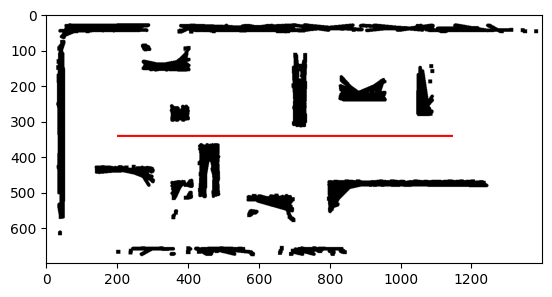

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [83]:
fig = plt.figure()
ax=fig.add_subplot()

def chaching_3(pos,part,grid,times):
    fig1 = plt.figure()
    ax1=fig1.add_subplot()
    for i in range(len(pos)):
        x.append(pos[i][1])
        y.append(pos[i][2])
        th.append(pos[i][0])
    #ax.scatter(x,y)
    ax1.scatter(part[1,:],part[2,:])
    ax1.plot(x,y,'r')
    ax1.imshow(grid)

    name="map"+str(times)+".png"
    fig1.savefig(name)
    fig1.clear()


xk=np.array([[0.0,200,340]]).T
meas=Lidar3(xk,(36*2,10*2),400) 

mapi3=Map()
mapi=Map(grid)

mapi3.sample_particles_gaussian(150)
parrr=0
i=0

x=[]
y=[]
th=[]
pos=[]

for i in range(350):
    meas=Lidar3(xk,(36*2,10*2),400)
    #if i%10==0:
    if(i%12==0 or i<5):
        lines = get_segment_boundaries(to_cart_all(xk, meas), 35)
        mapi3.fill_obs(lines)
        mapi3.update_belief(xk,meas)
        mapi3.draw_belief()
    
    meas=mapi3.update(400,xk)
    mapi3.predict(uk,par,std=(0.02, 0.02),dt=dt)

    if mapi3.should_resample(1):
        mapi3.resample_systematic()
        parrr+=1
    
    xk=rk4(par,xk,uk,3*dt)
    pos.append(xk)
    if i%2==0:
        print("Caching particles and belief at step", i)
        chaching_3(pos,mapi3.part,mapi3.grid,i)
    print(len(lines))
    #ax.scatter(mapi3.part[1,:],mapi3.part[2,:])
    
    #xk=rk4(par,xk,uk,dt)
    
for i in range(len(pos)):
        x.append(pos[i][1])
        y.append(pos[i][2])
        th.append(pos[i][0])

ax.imshow(mapi3.grid)
ax.plot(x,y,'r')
mapi3.lines=[]
print("Lines after update:", len(mapi3.lines))



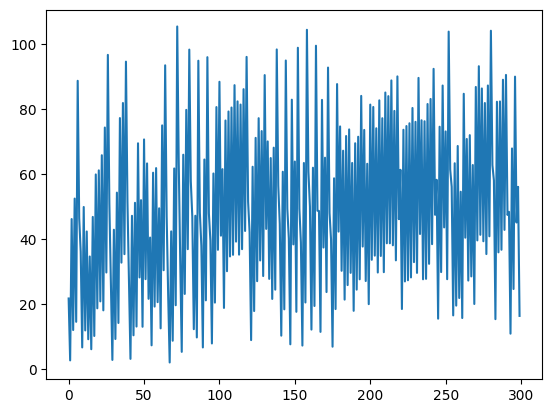

False


In [ ]:
plt.plot(mapi3.ess_lst)
plt.show()

print( not True)